# STAT 207 Homework 9 [25 points]

## Logistic Regression & Classifiers

Due: Thursday, November 7, end of day (11:59 pm CT)

<hr>

## Imports 

Run the following code cell to import the necessary packages into the file.  You may import additional packages, as needed for this assignment.

In [215]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
import numpy as np

## Case Study: Heart Disease

Can we identify patients who have heart disease based on other patient characteristics?

We will use the following information about patients:

- **age**: age
- **sex**: sex, 1 = male, 0 = female
- **cp**: chest pain type, 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic
- **trestbps**: resting blood pressure (in mm Hg)
- **chol**: serum cholesterol in mg/dl
- **fbs**: whether the fasting blood sugar is above 120 mg/dl (1 = true, 0 = false)
- **restecg**: resting electrocardiographic results (0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy)
- **thalach**: maximum heart rate achieved
- **exang**: exercise induced angina (1 = yes, 0 = no)
- **oldpeak**: ST depression induced by exercise relative to rest
- **slope**: the slope of the peak exercise ST segment (1 = upsloping, 2 = flat, 3 = downsloping)
- **ca**: number of major vessels (0-3) colored by flouroscopy (for calcification of vessels)
- **thal**: number of nuclear stress test (3 = normal, 6 = fixed defect, 7 = reversible defect)
- **num**: target number of progression of heart disease (1+ indicates at least 50% narrowing
- **y**: our target, generated below, for the presence of heart disease (1 = present, 0 = absent)

The data originally came from https://archive.ics.uci.edu/dataset/45/heart+disease.

Run the code in the cell below to read in the data for this document.  The data is saved as `df` with this code.  

In [216]:
df = pd.read_csv('processed_cleveland.csv', na_values = ['?'])
df = df.dropna()
df['y'] = 1 * (df['num'] > 0)
df['sex'] = df['sex'].replace({1: 'male', 0: 'female'})
df['cp'] = df['cp'].replace({1: 'typical', 2:'atypical', 3: 'non-anginal', 4: 'asymptomatic'})
df['fbs'] = df['fbs'].replace({1: 'high', 0: 'typical'})
df['restecg'] = df['restecg'].replace({0: 'normal', 1:'ST-T wave abnormality', 2: 'left ventricular hypertrophy'})
df['exang'] = df['exang'].replace({0: 'no', 1: 'yes'})
df['slope'] = df['slope'].replace({1:'upsloping', 2:'flat', 3:'downsloping'})
df['thal'] = df['thal'].replace({3: 'normal', 6: 'fixed defect', 7:'reversible defect'})

In [217]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,y
0,63,male,typical,145,233,high,left ventricular hypertrophy,150,no,2.3,downsloping,0.0,fixed defect,0,0
1,67,male,asymptomatic,160,286,typical,left ventricular hypertrophy,108,yes,1.5,flat,3.0,normal,2,1
2,67,male,asymptomatic,120,229,typical,left ventricular hypertrophy,129,yes,2.6,flat,2.0,reversible defect,1,1
3,37,male,non-anginal,130,250,typical,normal,187,no,3.5,downsloping,0.0,normal,0,0
4,41,female,atypical,130,204,typical,left ventricular hypertrophy,172,no,1.4,upsloping,0.0,normal,0,0


## 0. Prepare the Data [0.5 points]

Split the data into a training and a test data, using 20% as our test data and a random state of 1101.  We will use our training data exclusively for the first three questions of the assignment.  We won't turn to the test data until the last question.

In [218]:
train_data, test_data = train_test_split(df, test_size=0.20, random_state=1101)
print(train_data.shape)
print(test_data.shape)

(237, 15)
(60, 15)


## 1. Understand a Logistic Regression Model [2 points]

We know that we would like to predict the presence of heart disease (y).  First, we'll consider a simple model that uses age to predict the presence of heart disease.

**a)** Below, fit the model predicting the presence of heart disease from age.  Print the summary of the model.

In [219]:
hdis_from_age_model = smf.logit('y ~ age', data = train_data).fit()

hdis_age_mod_results = hdis_from_age_model.summary()
hdis_age_mod_results

Optimization terminated successfully.
         Current function value: 0.670429
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  237
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            1
Date:                Fri, 08 Nov 2024   Pseudo R-squ.:                 0.02997
Time:                        00:31:26   Log-Likelihood:                -158.89
converged:                       True   LL-Null:                       -163.80
Covariance Type:            nonrobust   LLR p-value:                  0.001728
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.6647      0.845     -3.153      0.002      -4.321      -1.008
age            0.0462      0.015      3.050      0.002       0.017       0.076
==============================================================================
"""

**b)** Generate the fitted vs. deviance residual plot for this model.

<Axes: >

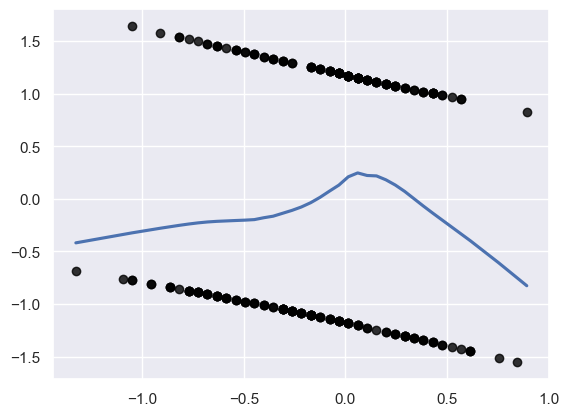

In [220]:
sns.regplot(x=hdis_from_age_model.fittedvalues, y=hdis_from_age_model.resid_dev, color="black", line_kws={"color": "b"}, lowess=True)

In [221]:
intercept = -2.6647
coef_age = 0.0462
age = 0

odds_age = np.exp(intercept + (coef_age * age))
print(f'When the age of a patient is 0, the predicted odds will be {odds_age}')

When the age of a patient is 0, the predicted odds will be 0.06962023647161314


In [222]:
age = 25

prob_age = 1 / (1 + np.exp(-(intercept + (coef_age * age))))
print(f'The predicted probability that a 25 year old has heart disease is {prob_age}')

The predicted probability that a 25 year old has heart disease is 0.18098325739173818


In [223]:
predict_threshold = 0.6
age_threshold = (np.log(predict_threshold / (1 - predict_threshold)) - intercept) / coef_age
print(f'If we set our predictive probability threshold at 0.6, the corresponding threshold for age would be {age_threshold}')

If we set our predictive probability threshold at 0.6, the corresponding threshold for age would be 66.45379021879143


In [224]:
np.exp(coef_age)

1.047283846782013

## 2. Fitting a More Complex Model [1 point]

We'd like to explore how effective advanced tests are at recognizing the risk of heart disease.  We'll fit a second model predicting y from age, sex, restecg, thalach, exang, oldpeak, slope, ca, and thal.  Be sure to print the output of your model below.

In [225]:
complex_model = smf.logit('y ~ age + sex + restecg + thalach + exang + oldpeak + slope + ca + thal', data=train_data).fit()

complex_model.summary()

Optimization terminated successfully.
         Current function value: 0.393922
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  237
Model:                          Logit   Df Residuals:                      224
Method:                           MLE   Df Model:                           12
Date:                Fri, 08 Nov 2024   Pseudo R-squ.:                  0.4300
Time:                        00:31:26   Log-Likelihood:                -93.359
converged:                       True   LL-Null:                       -163.80
Covariance Type:            nonrobust   LLR p-value:                 3.973e-24
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   1.1158      3.139      0.355      0.722      -5.037       7.269
sex[T.male]                                 0.7776      0.470      1.653      0.098      -0.144       1.699
restecg[T.left ventricular hypertrophy]    -0.3096      1.679     -0.184      0.854      -3.601       2.981
restecg[T.normal]                          -0.7972      1.685     -0.473      0.636      -4.099       2.505
exang[T.yes]                                0.8811      0.422      2.090      0.037       0.055       1.707
slope[T.flat]                               0.7029      0.721      0.974      0.330      -0.711       2.117
slope[T.upsloping]                         -0.1448      0.821     -0.176      0.860      -1.755       1.465
thal[T.normal]                             -0.4889      0.809     -0.605      0.545      -2.074       1.096
thal[T.reversible defect]                   1.0842      0.790      1.372      0.170      -0.465       2.633
age                                        -0.0101      0.024     -0.424      0.671      -0.057       0.037
thalach                                    -0.0159      0.010     -1.557      0.119      -0.036       0.004
oldpeak                                     0.3330      0.221      1.506      0.132      -0.100       0.766
ca                                          1.1300      0.258      4.378      0.000       0.624       1.636
===========================================================================================================
"""

In [226]:
from sklearn.metrics import roc_auc_score

y_train = train_data['y']
y_pred_probs = complex_model.predict(train_data)

auc = roc_auc_score(y_train, y_pred_probs)
auc

0.8983983983983984

## 3. Build a Classifier [1.5 points]

Using the model from Question 2, build a classifier to our training data using a predictive probability threshold of 0.75.  Then, generate a confusion matrix from this model.

In [227]:
from sklearn.metrics import confusion_matrix

train_pred_probs = complex_model.predict(train_data)

train_predictions = (train_pred_probs >= 0.75)

In [228]:
y_train = train_data['y']
conf_matrix = confusion_matrix(y_train, train_predictions)
conf_matrix

array([[121,   5],
       [ 41,  70]])

## 4. Test Data [1 point]

Finally, apply your logistic regression model from **Question 2** to your test data.  Calculate the predicted probabilities on your test data.

In [229]:
test_pred_probs = complex_model.predict(test_data)

test_pred_probs

115    0.327517
285    0.980741
228    0.823634
45     0.892525
143    0.835936
4      0.074651
109    0.658597
138    0.866591
77     0.273451
92     0.980514
276    0.280878
95     0.722033
193    0.903651
112    0.219690
260    0.257818
31     0.923132
235    0.973640
76     0.969527
9      0.828454
100    0.079176
99     0.075866
279    0.125399
157    0.813209
223    0.990434
293    0.983104
17     0.096713
216    0.028701
220    0.108859
155    0.971842
149    0.087689
204    0.275802
282    0.950334
186    0.255409
190    0.066534
111    0.793605
148    0.098452
67     0.470011
205    0.992184
300    0.947066
25     0.123618
11     0.174805
295    0.054532
24     0.990050
53     0.076472
30     0.363432
101    0.102757
202    0.474589
173    0.153200
255    0.066023
93     0.075734
124    0.490790
110    0.703339
33     0.471752
73     0.673256
20     0.583129
75     0.067523
297    0.626281
230    0.102844
133    0.161218
284    0.495606
dtype: float64

In [230]:
y_test = test_data['y']

test_auc = roc_auc_score(y_test, test_pred_probs)

test_auc

0.9739819004524887

In [231]:
test_auc > auc

True

Remember to keep all your cells and hit the save icon above periodically to checkpoint (save) your results on your local computer. Once you are satisified with your results restart the kernel and run all (Kernel -> Restart & Run All). **Make sure nothing has changed**. Checkpoint and exit (File -> Save and Checkpoint + File -> Close and Halt). Follow the instructions on the Homework 9 Canvas Assignment to submit your notebook to GitHub.